# Iris/Sigmet - Reader

In [1]:
import xarray as xr
from open_radar_data import DATASETS

import xradar as xd

## Download

Fetching Iris radar data file from [open-radar-data](https://github.com/openradar/open-radar-data) repository.

In [2]:
filename_single = DATASETS.fetch("SUR210819000227.RAWKPJV")
filename_volume = DATASETS.fetch("cor-main131125105503.RAW2049")

## xr.open_dataset

Making use of the xarray `iris` backend. We also need to provide the group. We use the group notation from `CfRadial2`.

In [3]:
ds = xr.open_dataset(filename_single, group="sweep_0", engine="iris")
display(ds)

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.Dataset> Size: 13MB
Dimensions:            (azimuth: 359, range: 833)
Coordinates:
  * azimuth            (azimuth) float32 1kB 0.03021 1.035 2.054 ... 358.0 359.0
    elevation          (azimuth) float32 1kB ...
    time               (azimuth) datetime64[ns] 3kB ...
  * range              (range) float32 3kB 150.0 450.0 ... 2.494e+05 2.498e+05
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           float64 8B ...
Data variables: (12/16)
    DBTH               (azimuth, range) float32 1MB ...
    DBZH               (azimuth, range) float32 1MB ...
    VRADH              (azimuth, range) float32 1MB ...
    WRADH              (azimuth, range) float32 1MB ...
    ZDR                (azimuth, range) float32 1MB ...
    KDP                (azimuth, range) float32 1MB ...
    ...                 ...
    SNRH               (azimuth, range) float32 1MB ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
Attributes:
    source:           Sigmet
    scan_name:        PPI1_H      
    instrument_name:  Surgavere, Radar
    comment:          Dual pol 250km hybrid surveillance task 0.5 deg 2.5minu...

### Plot Time vs. Azimuth

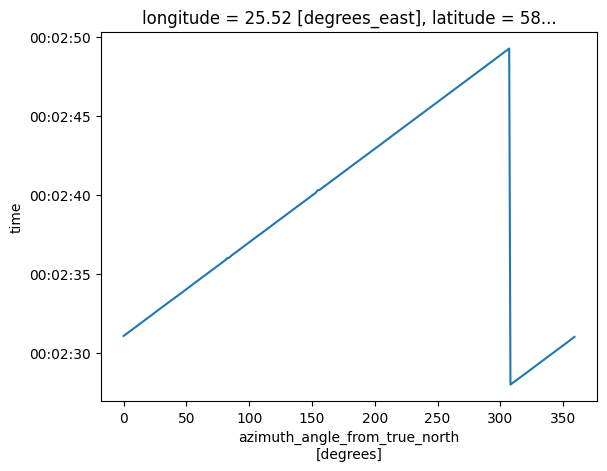

In [4]:
ds.azimuth.plot(y="time")

### Plot Range vs. Time

We need to sort by time and specify the y-coordinate.

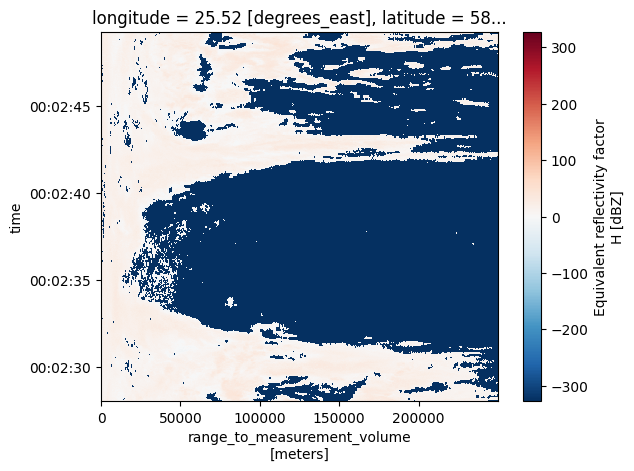

In [5]:
ds.DBZH.sortby("time").plot(y="time")

### Plot Range vs. Azimuth


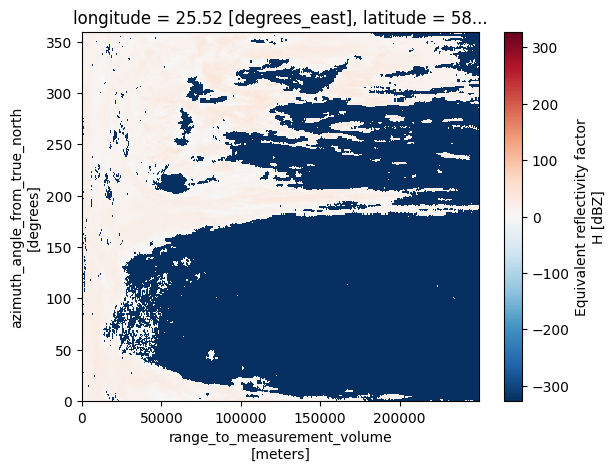

In [6]:
ds.DBZH.plot(y="azimuth")

## backend_kwargs

Beside `first_dim` there are several additional backend_kwargs for the iris backend, which handle different aspects of angle alignment. This comes into play, when azimuth and/or elevation arrays are not evenly spacend and other issues.

In [7]:
help(xd.io.IrisBackendEntrypoint)

Help on class IrisBackendEntrypoint in module xradar.io.backends.iris:

class IrisBackendEntrypoint(xarray.backends.common.BackendEntrypoint)
 |  Xarray BackendEntrypoint for IRIS/Sigmet data.
 |
 |  Method resolution order:
 |      IrisBackendEntrypoint
 |      xarray.backends.common.BackendEntrypoint
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  open_dataset(
 |      self,
 |      filename_or_obj,
 |      *,
 |      mask_and_scale=True,
 |      decode_times=True,
 |      concat_characters=True,
 |      decode_coords=True,
 |      drop_variables=None,
 |      use_cftime=None,
 |      decode_timedelta=None,
 |      group=None,
 |      lock=None,
 |      first_dim='auto',
 |      reindex_angle=False,
 |      fix_second_angle=False,
 |      site_coords=True,
 |      optional=True
 |  )
 |      Backend open_dataset method used by Xarray in :py:func:`~xarray.open_dataset`.
 |
 |  ----------------------------------------------------------------------
 |  Data and other attribu

In [8]:
ds = xr.open_dataset(filename_single, group="sweep_0", engine="iris", first_dim="time")
display(ds)

<xarray.Dataset> Size: 13MB
Dimensions:            (time: 359, range: 833)
Coordinates:
    azimuth            (time) float32 1kB ...
    elevation          (time) float32 1kB ...
  * time               (time) datetime64[ns] 3kB 2021-08-19T00:02:28.029000 ....
  * range              (range) float32 3kB 150.0 450.0 ... 2.494e+05 2.498e+05
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           float64 8B ...
Data variables: (12/16)
    DBTH               (time, range) float32 1MB ...
    DBZH               (time, range) float32 1MB ...
    VRADH              (time, range) float32 1MB ...
    WRADH              (time, range) float32 1MB ...
    ZDR                (time, range) float32 1MB ...
    KDP                (time, range) float32 1MB ...
    ...                 ...
    SNRH               (time, range) float32 1MB ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
Attributes:
    source:           Sigmet
    scan_name:        PPI1_H      
    instrument_name:  Surgavere, Radar
    comment:          Dual pol 250km hybrid surveillance task 0.5 deg 2.5minu...

## open_iris_datatree

The same works analoguous with the datatree loader. But additionally we can provide a sweep string, number or list. The underlying xarray.Dataset can be accessed with property `.ds`.

In [9]:
help(xd.io.open_iris_datatree)

Help on function open_iris_datatree in module xradar.io.backends.iris:

open_iris_datatree(filename_or_obj, **kwargs)
    Open Iris/Sigmet dataset as :py:class:`xarray.DataTree`.

    Parameters
    ----------
    filename_or_obj : str, Path, file-like or DataStore
        Strings and Path objects are interpreted as a path to a local or remote
        radar file

    Keyword Arguments
    -----------------
    sweep : int, list of int, optional
        Sweep number(s) to extract, default to first sweep. If None, all sweeps are
        extracted into a list.
    first_dim : str
        Can be ``time`` or ``auto`` first dimension. If set to ``auto``,
        first dimension will be either ``azimuth`` or ``elevation`` depending on
        type of sweep. Defaults to ``auto``.
    reindex_angle : bool or dict
        Defaults to False, no reindexing. Given dict should contain the kwargs to
        reindex_angle. Only invoked if `decode_coord=True`.
    fix_second_angle : bool
        If Tru

In [10]:
dtree = xd.io.open_iris_datatree(filename_volume)
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 10)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2013-11-25T10:55:04Z'
│       time_coverage_end    <U20 80B '2013-11-25T10:59:24Z'
│       longitude            float64 8B -75.28
│       altitude             float64 8B 143.0
│       latitude             float64 8B 9.331
│       sweep_fixed_angle    (sweep) float64 80B 0.5 1.0 2.0 3.0 ... 15.0 20.0 30.0
│       sweep_group_name     (sweep) int64 80B 0 1 2 3 4 5 6 7 8 9
│   Attributes:
│       Conventions:      None
│       instrument_name:  Corozal, Radar
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           Sigmet
│       history:          None
│       comment:          AEROCIVIL OPERATIONAL DUAL POLE SCAN
│       scan_name:        SURV_HV_300 
├── Group: /sweep_0
│       Dimensions:            (azimuth: 360, range: 664)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.02197 1.134 2.09 ... 358.0 359.0
│           elevation          (azimuth) float32 1kB ...
│           time               (azimuth) datetime64[ns] 3kB 2013-11-25T10:55:14.54100...
│         * range              (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float32 956kB ...
│           VRADH              (azimuth, range) float32 956kB ...
│           ZDR                (azimuth, range) float32 956kB ...
│           KDP                (azimuth, range) float32 956kB ...
│           PHIDP              (azimuth, range) float32 956kB ...
│           RHOHV              (azimuth, range) float32 956kB ...
│           DB_HCLASS          (azimuth, range) int16 478kB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /sweep_1
│       Dimensions:            (azimuth: 360, range: 664)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.06042 1.016 2.054 ... 358.0 359.0
│           elevation          (azimuth) float32 1kB ...
│           time               (azimuth) datetime64[ns] 3kB 2013-11-25T10:55:38.62000...
│         * range              (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float32 956kB ...
│           VRADH              (azimuth, range) float32 956kB ...
│           ZDR                (azimuth, range) float32 956kB ...
│           KDP                (azimuth, range) float32 956kB ...
│           PHIDP              (azimuth, range) float32 956kB ...
│           RHOHV              (azimuth, range) float32 956kB ...
│           DB_HCLASS          (azimuth, range) int16 478kB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /sweep_2
│       Dimensions:            (azimuth: 360, range: 664)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.09064 0.9778 ... 358.0 359.1
│           elevation          (azimuth) float32 1kB ...
│           time               (azimuth) datetime64[ns] 3kB 2013-11-25T10:56:02.78100...
│         * range              (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
│        

In [11]:
dtree = xd.io.open_iris_datatree(filename_volume, sweep="sweep_8")
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2013-11-25T10:58:33Z'
│       time_coverage_end    <U20 80B '2013-11-25T10:58:57Z'
│       longitude            float64 8B -75.28
│       altitude             float64 8B 143.0
│       latitude             float64 8B 9.331
│       sweep_fixed_angle    (sweep) float64 8B 20.0
│       sweep_group_name     (sweep) int64 8B 8
│   Attributes:
│       Conventions:      None
│       instrument_name:  Corozal, Radar
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           Sigmet
│       history:          None
│       comment:          AEROCIVIL OPERATIONAL DUAL POLE SCAN
│       scan_name:        SURV_HV_300 
├── Group: /sweep_0
│       Dimensions:            (azimuth: 360, range: 664)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.06042 1.079 2.008 ... 358.0 359.1
│           elevation          (azimuth) float32 1kB ...
│           time               (azimuth) datetime64[ns] 3kB 2013-11-25T10:58:51.47000...
│         * range              (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float32 956kB ...
│           VRADH              (azimuth, range) float32 956kB ...
│           ZDR                (azimuth, range) float32 956kB ...
│           KDP                (azimuth, range) float32 956kB ...
│           PHIDP              (azimuth, range) float32 956kB ...
│           RHOHV              (azimuth, range) float32 956kB ...
│           DB_HCLASS          (azimuth, range) int16 478kB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
└── Group: /radar_calibration

In [12]:
dtree = xd.io.open_iris_datatree(filename_volume, sweep=[1, 2, 8])
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 3)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2013-11-25T10:55:30Z'
│       time_coverage_end    <U20 80B '2013-11-25T10:58:57Z'
│       longitude            float64 8B -75.28
│       altitude             float64 8B 143.0
│       latitude             float64 8B 9.331
│       sweep_fixed_angle    (sweep) float64 24B 1.0 2.0 20.0
│       sweep_group_name     (sweep) int64 24B 1 2 8
│   Attributes:
│       Conventions:      None
│       instrument_name:  Corozal, Radar
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           Sigmet
│       history:          None
│       comment:          AEROCIVIL OPERATIONAL DUAL POLE SCAN
│       scan_name:        SURV_HV_300 
├── Group: /sweep_0
│       Dimensions:            (azimuth: 360, range: 664)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.06042 1.016 2.054 ... 358.0 359.0
│           elevation          (azimuth) float32 1kB ...
│           time               (azimuth) datetime64[ns] 3kB 2013-11-25T10:55:38.62000...
│         * range              (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float32 956kB ...
│           VRADH              (azimuth, range) float32 956kB ...
│           ZDR                (azimuth, range) float32 956kB ...
│           KDP                (azimuth, range) float32 956kB ...
│           PHIDP              (azimuth, range) float32 956kB ...
│           RHOHV              (azimuth, range) float32 956kB ...
│           DB_HCLASS          (azimuth, range) int16 478kB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /sweep_1
│       Dimensions:            (azimuth: 360, range: 664)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.09064 0.9778 ... 358.0 359.1
│           elevation          (azimuth) float32 1kB ...
│           time               (azimuth) datetime64[ns] 3kB 2013-11-25T10:56:02.78100...
│         * range              (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float32 956kB ...
│           VRADH              (azimuth, range) float32 956kB ...
│           ZDR                (azimuth, range) float32 956kB ...
│           KDP                (azimuth, range) float32 956kB ...
│           PHIDP              (azimuth, range) float32 956kB ...
│           RHOHV              (azimuth, range) float32 956kB ...
│           DB_HCLASS          (azimuth, range) int16 478kB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /sweep_2
│       Dimensions:            (azimuth: 360, range: 664)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.06042 1.079 2.008 ... 358.0 359.1
│           elevation          (azimuth) float32 1kB ...
│           time               (azimuth) datetime64[ns] 3kB 2013-11-25T10:58:51.47000...
│         * range              (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
│           longitude          float64 8B ...

In [13]:
dtree = xd.io.open_iris_datatree(
    filename_volume,
    sweep=["sweep_0", "sweep_1", "sweep_8"],
)
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 3)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2013-11-25T10:55:04Z'
│       time_coverage_end    <U20 80B '2013-11-25T10:58:57Z'
│       longitude            float64 8B -75.28
│       altitude             float64 8B 143.0
│       latitude             float64 8B 9.331
│       sweep_fixed_angle    (sweep) float64 24B 0.5 1.0 20.0
│       sweep_group_name     (sweep) int64 24B 0 1 8
│   Attributes:
│       Conventions:      None
│       instrument_name:  Corozal, Radar
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           Sigmet
│       history:          None
│       comment:          AEROCIVIL OPERATIONAL DUAL POLE SCAN
│       scan_name:        SURV_HV_300 
├── Group: /sweep_0
│       Dimensions:            (azimuth: 360, range: 664)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.02197 1.134 2.09 ... 358.0 359.0
│           elevation          (azimuth) float32 1kB ...
│           time               (azimuth) datetime64[ns] 3kB 2013-11-25T10:55:14.54100...
│         * range              (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float32 956kB ...
│           VRADH              (azimuth, range) float32 956kB ...
│           ZDR                (azimuth, range) float32 956kB ...
│           KDP                (azimuth, range) float32 956kB ...
│           PHIDP              (azimuth, range) float32 956kB ...
│           RHOHV              (azimuth, range) float32 956kB ...
│           DB_HCLASS          (azimuth, range) int16 478kB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /sweep_1
│       Dimensions:            (azimuth: 360, range: 664)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.06042 1.016 2.054 ... 358.0 359.0
│           elevation          (azimuth) float32 1kB ...
│           time               (azimuth) datetime64[ns] 3kB 2013-11-25T10:55:38.62000...
│         * range              (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float32 956kB ...
│           VRADH              (azimuth, range) float32 956kB ...
│           ZDR                (azimuth, range) float32 956kB ...
│           KDP                (azimuth, range) float32 956kB ...
│           PHIDP              (azimuth, range) float32 956kB ...
│           RHOHV              (azimuth, range) float32 956kB ...
│           DB_HCLASS          (azimuth, range) int16 478kB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /sweep_2
│       Dimensions:            (azimuth: 360, range: 664)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.06042 1.079 2.008 ... 358.0 359.1
│           elevation          (azimuth) float32 1kB ...
│           time               (azimuth) datetime64[ns] 3kB 2013-11-25T10:58:51.47000...
│         * range              (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
│           longitude          float64 8B

### Plot Time vs. Azimuth

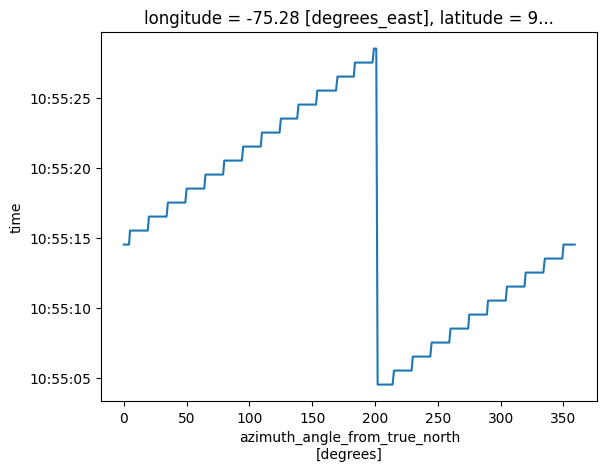

In [14]:
dtree["sweep_0"].ds.azimuth.plot(y="time")

### Plot Sweep Range vs. Time

We need to sort by time and specify the y-coordinate. Please also observe the different resolutions of this plot, compared to the `Azimuth vs. Range` plot below. This is due to second-resolution of the time coordinate.

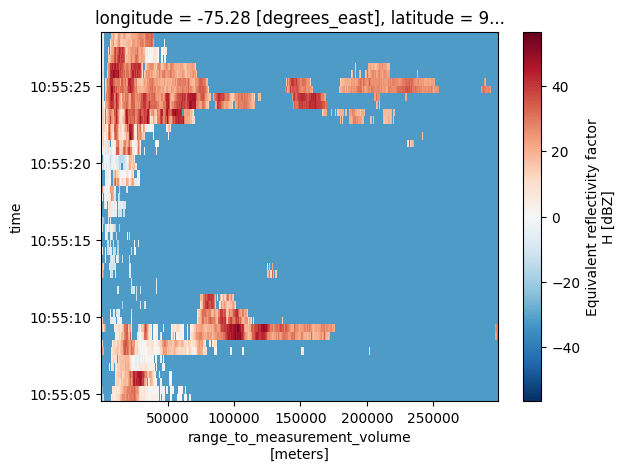

In [15]:
dtree["sweep_0"].ds.DBZH.sortby("time").plot(y="time")

### Plot Sweep Range vs. Azimuth

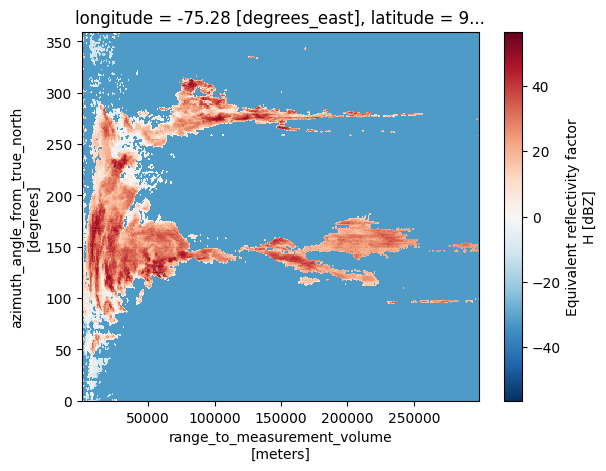

In [16]:
dtree["sweep_0"].ds.DBZH.plot()